# CMIP6 Case A — Step 4: Spatial P–ET–R relationships in the 30-year climatology

**English.** This notebook treats each non-ice land grid cell as one observation and analyzes spatial relationships among 1985–2014 mean precipitation (P), evapotranspiration (ET), and runoff (R). It focuses on nonlinear spatial structure and climatological water partitioning. It does not use annual years as independent samples, fit a tree model, or define climate classes.

**中文。** 本 notebook 将每个非冰川陆地网格作为一个观测样本，分析 1985–2014 年平均降水（P）、蒸散发（ET）和径流（R）之间的空间关系，重点关注非线性空间结构和长期水分分配。本步骤不再把30个年份当作独立样本，不建立 tree，也不定义新的气候类别。


## Step 0 — Configuration and plotting style

**English.** Locate the Step 2 climatology products, use non-ice land area as the spatial weight, and retain the Robinson map style used in the preceding case figures. Maps display 60°S–90°N to emphasize the analyzed non-ice terrestrial domain; the underlying data are not cropped.

**中文。** 定位 Step 2 的30年气候态产品，使用非冰川陆地面积作为空间权重，并继续采用前面 case 图中的 Robinson 投影风格。地图显示范围为 60°S–90°N，以突出非冰川陆地区域；底层数据不会被裁剪。


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
from scipy.interpolate import PchipInterpolator
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 220,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "axes.edgecolor": "#30343B",
    "axes.linewidth": 0.9, "axes.titlesize": 11,
    "axes.titleweight": "semibold", "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

START_YEAR, END_YEAR = 1985, 2014
N_AREA_BINS = 15
WRITE_OUTPUTS = True

def find_case_dir(start=Path.cwd()):
    start = start.resolve()
    for base in (start, *start.parents):
        if base.name.lower() == "casea":
            return base
        candidate = base / "case" / "caseA"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate case/caseA.")

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#30343B")
        spine.set_linewidth(0.9)
    ax.tick_params(direction="out", length=3.5, width=0.75, color="#30343B")
    ax.grid(True, color="#E1E5EA", linewidth=0.55, alpha=0.85, zorder=0)

CASE_DIR = find_case_dir()
DERIVED_DIR = CASE_DIR / "derived"
FIGURE_DIR = DERIVED_DIR / "figures_step4"
CLIMATOLOGY_TABLE = DERIVED_DIR / "MPI_ESM1_2_LR_water_cycle_climatology_1985_2014.parquet"
ANNUAL_NETCDF = DERIVED_DIR / "MPI_ESM1_2_LR_water_cycle_annual_1985_2014.nc"

print(f"Case directory: {CASE_DIR}")
print(f"Analysis unit: one 1985–2014 mean value per non-ice land grid cell")


Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Analysis unit: one 1985–2014 mean value per non-ice land grid cell


## Step 1 — Load the climatology and define unambiguous partition fractions

**English.** Load the one-row-per-grid climatology table. For this spatial analysis, define ET fraction and runoff fraction as ratios of 30-year mean fluxes:

\[
f_{ET}=\overline{ET}/\overline{P},\qquad
f_R=\overline{R}/\overline{P}.
\]

This differs from averaging 30 annual ET/P or R/P ratios. The ratio of means is the appropriate quantity when the analysis unit is the 30-year climatological grid cell. The original Step 2 ratio columns are preserved for provenance but are not used as the primary Step 4 fractions.

**中文。** 读取每个网格一行的30年气候态表。对于本次空间分析，将 ET 比例和径流比例明确计算为30年平均通量之比：

\[
f_{ET}=\overline{ET}/\overline{P},\qquad
f_R=\overline{R}/\overline{P}.
\]

这与“先计算每年的 ET/P 或 R/P，再对30年取平均”并不相同。当分析单位是30年平均网格时，平均值之比更符合当前问题。Step 2 原有比例列保留用于追溯，但不作为 Step 4 的主要比例变量。


In [2]:
if not CLIMATOLOGY_TABLE.exists() or not ANNUAL_NETCDF.exists():
    raise FileNotFoundError("Run CMIP_step2_prepare_annual_dataset.ipynb first.")

clim = pd.read_parquet(CLIMATOLOGY_TABLE).sort_values("grid_id").reset_index(drop=True)
spatial = xr.open_dataset(ANNUAL_NETCDF)

clim["ET_fraction_climatology"] = clim["ET"] / clim["P"]
clim["R_fraction_climatology"] = clim["R"] / clim["P"]
clim["WB_fraction_climatology"] = clim["WB"] / clim["P"]
clim["partition_sum_climatology"] = (clim["ET"] + clim["R"]) / clim["P"]
clim["log10_P"] = np.log10(clim["P"])

ratio_audit = pd.Series({
    "grid_cells": len(clim),
    "unique_grid_ids": clim["grid_id"].nunique(),
    "minimum_P_mm_yr": float(clim["P"].min()),
    "maximum_P_mm_yr": float(clim["P"].max()),
    "median_abs_difference_ET_fraction_definitions": float(
        (clim["ET_over_P"] - clim["ET_fraction_climatology"]).abs().median()
    ),
    "median_abs_difference_R_fraction_definitions": float(
        (clim["R_over_P"] - clim["R_fraction_climatology"]).abs().median()
    ),
    "duplicate_grid_ids": int(clim["grid_id"].duplicated().sum()),
    "missing_primary_values": int(clim[["P", "ET", "R", "WB", "land_area"]].isna().sum().sum()),
})
display(ratio_audit.to_frame("value"))

assert ratio_audit["grid_cells"] == ratio_audit["unique_grid_ids"] == int(spatial["analysis_cell"].sum())
assert ratio_audit["duplicate_grid_ids"] == 0
assert ratio_audit["missing_primary_values"] == 0
assert (clim["P"] > 0).all()


,value
grid_cells,4172.000000
unique_grid_ids,4172.000000
minimum_P_mm_yr,0.363837
maximum_P_mm_yr,3543.200195
median_abs_difference_ET_fraction_definitions,0.009584
median_abs_difference_R_fraction_definitions,0.002312
duplicate_grid_ids,0.000000
missing_primary_values,0.000000


## Step 2 — Area-weighted spatial association

**English.** Calculate area-weighted Pearson and rank correlations across grid cells. These statistics describe spatial co-variation of 30-year means, not year-to-year dynamics. They are descriptive because neighboring grid cells are spatially autocorrelated. The rank correlation helps reveal whether a relationship is monotonic even when it is nonlinear.

**中文。** 在所有网格之间计算面积加权 Pearson 相关和秩相关。这些指标描述的是30年平均值的空间共同变化，而不是单个网格内部的年际关系。由于相邻网格存在空间自相关，这里只做描述性解释。秩相关可用于判断非线性关系是否仍保持总体单调。


In [3]:
def weighted_quantile(values, weights, quantile=0.5):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    order = np.argsort(values[valid])
    sorted_values = values[valid][order]
    sorted_weights = weights[valid][order]
    cumulative = np.cumsum(sorted_weights)
    return float(sorted_values[np.searchsorted(cumulative, quantile * cumulative[-1])])

def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return float(np.average(values[valid], weights=weights[valid]))

def weighted_pearson(x, y, weights):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(weights) & (weights > 0)
    x, y, weights = x[valid], y[valid], weights[valid]
    x_mean = np.average(x, weights=weights)
    y_mean = np.average(y, weights=weights)
    covariance = np.sum(weights * (x - x_mean) * (y - y_mean))
    denominator = np.sqrt(
        np.sum(weights * (x - x_mean) ** 2) * np.sum(weights * (y - y_mean) ** 2)
    )
    return float(covariance / denominator)

def weighted_spearman(x, y, weights):
    x_rank = pd.Series(x).rank(method="average").to_numpy()
    y_rank = pd.Series(y).rank(method="average").to_numpy()
    return weighted_pearson(x_rank, y_rank, weights)

weights = clim["land_area"].astype(float)
relationship_pairs = [
    ("P", "ET", "P–ET"),
    ("P", "R", "P–R"),
    ("ET", "R", "ET–R"),
    ("P", "ET_fraction_climatology", "P–ET/P"),
    ("P", "R_fraction_climatology", "P–R/P"),
]
correlation_summary = pd.DataFrame([
    {
        "relationship": label,
        "area_weighted_Pearson_r": weighted_pearson(clim[x], clim[y], weights),
        "area_weighted_rank_r": weighted_spearman(clim[x], clim[y], weights),
    }
    for x, y, label in relationship_pairs
]).set_index("relationship")
display(correlation_summary.round(3))


,area_weighted_Pearson_r,area_weighted_rank_r
relationship,,
P–ET,0.909,0.932
P–R,0.717,0.771
ET–R,0.361,0.553
P–ET/P,-0.339,-0.422
P–R/P,0.334,0.416


## Step 3 — Examine spatial flux relationships

**English.** Plot all 4,172 grid cells as small, equal-size solid points following the clean reference-figure style. A smooth area-weighted binned-median curve summarizes the relationship without covering the observations; no density layer or interquartile shading is added. Equal-land-area bins prevent densely sampled high latitudes from dominating the summary curve.

**中文。** 参考示例图的简洁风格，将全部 4,172 个网格绘制为小而等大的实心散点。只叠加一条平滑的面积加权分箱中位数曲线，不添加密度层或四分位阴影，避免遮住单个观测点。使用等陆地面积分箱，可避免网格更密集的高纬度区域主导趋势曲线。


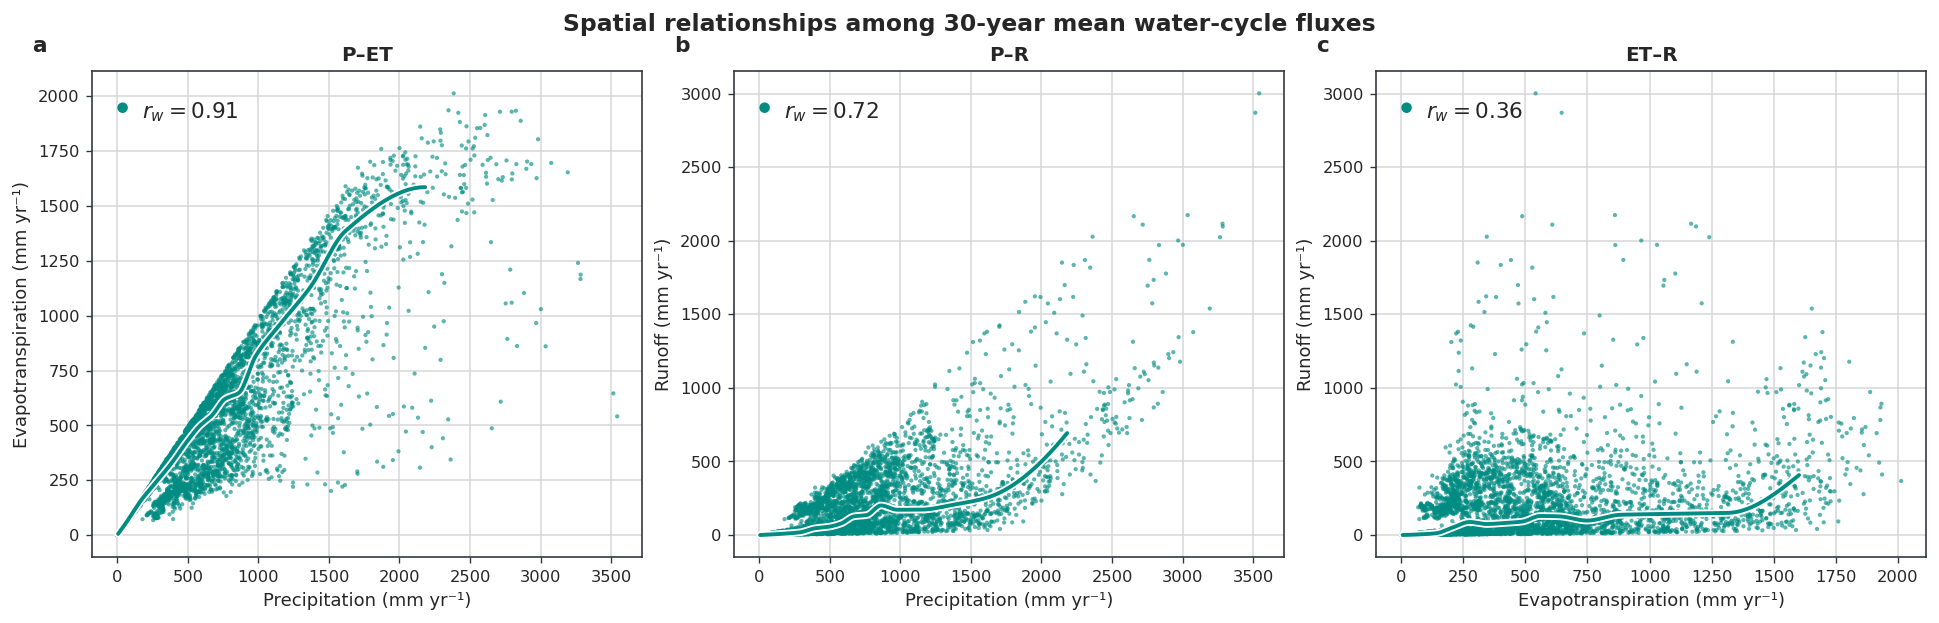

In [4]:
def weighted_binned_summary(frame, x, variables, weight_col="land_area", n_bins=N_AREA_BINS):
    x_values = frame[x].to_numpy(float)
    w_values = frame[weight_col].to_numpy(float)
    edges = np.array([weighted_quantile(x_values, w_values, q) for q in np.linspace(0, 1, n_bins + 1)])
    edges = np.unique(edges)
    labels = pd.cut(frame[x], edges, include_lowest=True, duplicates="drop")
    rows = []
    for bin_number, (_, group) in enumerate(frame.groupby(labels, observed=True), start=1):
        row = {
            "bin": bin_number,
            "n_grid_cells": len(group),
            "land_area": group[weight_col].sum(),
            f"{x}_median": weighted_quantile(group[x], group[weight_col], 0.5),
            f"{x}_q25": weighted_quantile(group[x], group[weight_col], 0.25),
            f"{x}_q75": weighted_quantile(group[x], group[weight_col], 0.75),
        }
        for variable in variables:
            row[f"{variable}_median"] = weighted_quantile(group[variable], group[weight_col], 0.5)
            row[f"{variable}_q25"] = weighted_quantile(group[variable], group[weight_col], 0.25)
            row[f"{variable}_q75"] = weighted_quantile(group[variable], group[weight_col], 0.75)
        rows.append(row)
    return pd.DataFrame(rows)

scatter_specs = [
    ("P", "ET", "P–ET", "Precipitation (mm yr⁻¹)", "Evapotranspiration (mm yr⁻¹)"),
    ("P", "R", "P–R", "Precipitation (mm yr⁻¹)", "Runoff (mm yr⁻¹)"),
    ("ET", "R", "ET–R", "Evapotranspiration (mm yr⁻¹)", "Runoff (mm yr⁻¹)"),
]
point_sizes = np.full(len(clim), 5.5)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(14.8, 4.5), constrained_layout=True)
for panel, (ax, (x, y, label, xlabel, ylabel)) in enumerate(zip(axes, scatter_specs)):
    ax.scatter(
        clim[x], clim[y], s=point_sizes, color="#008C82", alpha=0.64,
        edgecolors="none", rasterized=True, zorder=2,
    )
    curve = weighted_binned_summary(clim, x, [y])
    x_curve = curve[f"{x}_median"].to_numpy()
    y_curve = curve[f"{y}_median"].to_numpy()
    smooth_x = np.linspace(x_curve.min(), x_curve.max(), 300)
    smooth_y = PchipInterpolator(x_curve, y_curve)(smooth_x)
    ax.plot(smooth_x, smooth_y, color="white", linewidth=4.2, zorder=3)
    ax.plot(smooth_x, smooth_y, color="#008C82", linewidth=2.15, zorder=4)
    r_value = correlation_summary.loc[label, "area_weighted_Pearson_r"]
    ax.scatter([0.055], [0.925], transform=ax.transAxes, s=34, color="#008C82", edgecolors="none", clip_on=False, zorder=5)
    ax.text(0.09, 0.94, rf"$r_w = {r_value:.2f}$", transform=ax.transAxes, va="top")
    ax.set_title(label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.text(-0.11, 1.04, chr(97 + panel), transform=ax.transAxes, fontweight="bold")
    style_axes(ax)
    ax.grid(True, color="#D3D3D3", linewidth=0.9, alpha=0.85, zorder=0)
fig.suptitle("Spatial relationships among 30-year mean water-cycle fluxes", y=1.03, fontsize=13, fontweight="semibold")
fig.savefig(FIGURE_DIR / "climatology_spatial_flux_relationships.png", bbox_inches="tight")
plt.show()


## Step 4 — Follow water partitioning along the precipitation gradient

**English.** Use equal-land-area precipitation bins to show how climatological ET, R, ET/P, and R/P change from dry to wet grids. The flux panel asks how the two outputs grow with P. The fraction panel asks how the same precipitation input is partitioned. Because ET/P + R/P ≈ 1 when long-term storage change is small, the two fractions are complementary rather than independent responses.

**中文。** 使用等陆地面积的降水分箱，展示从干旱网格到湿润网格时，长期 ET、R、ET/P 和 R/P 如何变化。通量图回答 ET 与 R 如何随 P 增加；比例图回答相同降水输入如何在 ET 和 R 之间分配。当长期储水变化较小时，ET/P + R/P ≈ 1，因此两个比例是互补结果，而不是彼此独立的响应变量。


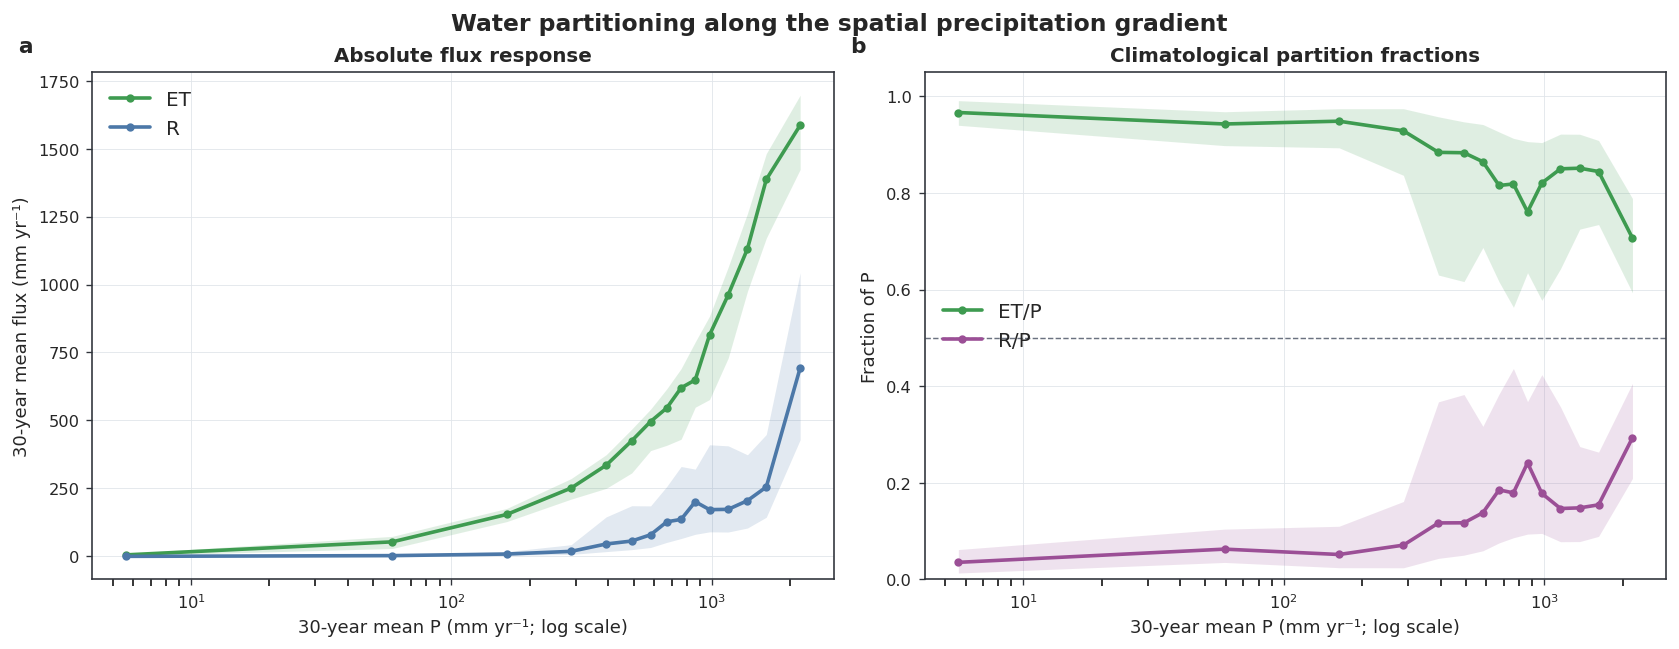

,bin,n_grid_cells,land_area,P_median,P_q25,P_q75,ET_median,ET_q25,ET_q75,R_median,...,R_q75,ET_fraction_climatology_median,ET_fraction_climatology_q25,ET_fraction_climatology_q75,R_fraction_climatology_median,R_fraction_climatology_q25,R_fraction_climatology_q75,WB_fraction_climatology_median,WB_fraction_climatology_q25,WB_fraction_climatology_q75
0,1,222,8.769985e+12,5.629,2.346,10.918,5.558,2.364,10.438,0.178,...,0.545,0.966,0.940,0.991,0.035,0.013,0.062,-0.005,-0.016,0.005
1,2,232,8.751148e+12,59.285,31.166,81.442,53.494,29.035,73.666,2.811,...,5.781,0.943,0.898,0.968,0.063,0.035,0.104,-0.001,-0.007,0.001
2,3,243,8.770336e+12,163.002,136.294,191.313,154.239,127.962,176.375,8.583,...,17.576,0.948,0.893,0.974,0.052,0.024,0.110,-0.001,-0.003,0.001
3,4,321,8.732008e+12,287.965,258.275,315.733,251.294,210.591,286.165,18.499,...,42.919,0.929,0.836,0.974,0.071,0.024,0.161,-0.000,-0.002,0.002
4,5,345,8.755193e+12,392.697,362.624,417.869,335.373,250.216,373.974,45.639,...,145.238,0.884,0.630,0.957,0.117,0.044,0.368,0.000,-0.002,0.002
5,6,340,8.772655e+12,492.091,467.428,512.674,425.044,306.916,468.118,56.486,...,186.303,0.883,0.616,0.947,0.117,0.050,0.383,-0.000,-0.002,0.002
6,7,327,8.740318e+12,581.462,559.032,602.638,496.018,389.101,541.497,79.568,...,185.730,0.865,0.687,0.942,0.138,0.059,0.317,-0.000,-0.002,0.001
7,8,337,8.775838e+12,671.093,647.447,693.472,545.960,408.700,616.452,127.144,...,257.353,0.815,0.616,0.926,0.185,0.076,0.384,-0.001,-0.002,0.001
8,9,314,8.762792e+12,761.664,739.613,787.290,620.049,430.883,690.738,136.132,...,330.611,0.819,0.563,0.913,0.179,0.086,0.437,-0.000,-0.002,0.002
9,10,300,8.742411e+12,862.937,835.491,887.919,649.135,548.646,788.810,201.119,...,320.896,0.761,0.635,0.906,0.241,0.094,0.368,-0.000,-0.002,0.001


In [5]:
precipitation_bins = weighted_binned_summary(
    clim,
    "P",
    ["ET", "R", "ET_fraction_climatology", "R_fraction_climatology", "WB_fraction_climatology"],
)

x_curve = precipitation_bins["P_median"].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.7), constrained_layout=True)

for variable, label, color in [("ET", "ET", "#3E9B50"), ("R", "R", "#4C78A8")]:
    axes[0].fill_between(
        x_curve,
        precipitation_bins[f"{variable}_q25"].to_numpy(),
        precipitation_bins[f"{variable}_q75"].to_numpy(),
        color=color, alpha=0.16, linewidth=0,
    )
    axes[0].plot(
        x_curve, precipitation_bins[f"{variable}_median"],
        color=color, marker="o", markersize=3.6, linewidth=2, label=label,
    )
axes[0].set_xscale("log")
axes[0].set_xlabel("30-year mean P (mm yr⁻¹; log scale)")
axes[0].set_ylabel("30-year mean flux (mm yr⁻¹)")
axes[0].set_title("Absolute flux response")
axes[0].legend(frameon=False)
style_axes(axes[0])

fraction_specs = [
    ("ET_fraction_climatology", "ET/P", "#3E9B50"),
    ("R_fraction_climatology", "R/P", "#9B4F96"),
]
for variable, label, color in fraction_specs:
    axes[1].fill_between(
        x_curve,
        precipitation_bins[f"{variable}_q25"].to_numpy(),
        precipitation_bins[f"{variable}_q75"].to_numpy(),
        color=color, alpha=0.16, linewidth=0,
    )
    axes[1].plot(
        x_curve, precipitation_bins[f"{variable}_median"],
        color=color, marker="o", markersize=3.6, linewidth=2, label=label,
    )
axes[1].axhline(0.5, color="#6B7280", linewidth=0.8, linestyle="--")
axes[1].set_xscale("log")
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("30-year mean P (mm yr⁻¹; log scale)")
axes[1].set_ylabel("Fraction of P")
axes[1].set_title("Climatological partition fractions")
axes[1].legend(frameon=False)
style_axes(axes[1])

for panel, ax in enumerate(axes):
    ax.text(-0.10, 1.04, chr(97 + panel), transform=ax.transAxes, fontweight="bold")
fig.suptitle("Water partitioning along the spatial precipitation gradient", y=1.03, fontsize=13, fontweight="semibold")
fig.savefig(FIGURE_DIR / "precipitation_partition_curves.png", bbox_inches="tight")
plt.show()

display(precipitation_bins.round(3))


## Step 5 — Map climatological partition fractions

**English.** Map ET/P and R/P on the model grid using the established Robinson style. The maps reveal where the spatial curves come from: dry and water-limited regions generally return most P to ET, while runoff fractions are larger in selected wet, mountainous, or cool regions. The maps are descriptive; temperature, radiation, snow, and soil moisture are needed to test those mechanisms.

**中文。** 使用统一的 Robinson 风格，在模式网格上绘制 ET/P 与 R/P。地图用于解释空间曲线来自哪些地区：干旱和长期水分限制明显的区域通常将较大比例的 P 分配给 ET，而部分湿润、山地或寒冷区域的径流比例更高。这里仍是描述性结果；若要验证机制，还需要温度、辐射、积雪和土壤水分变量。


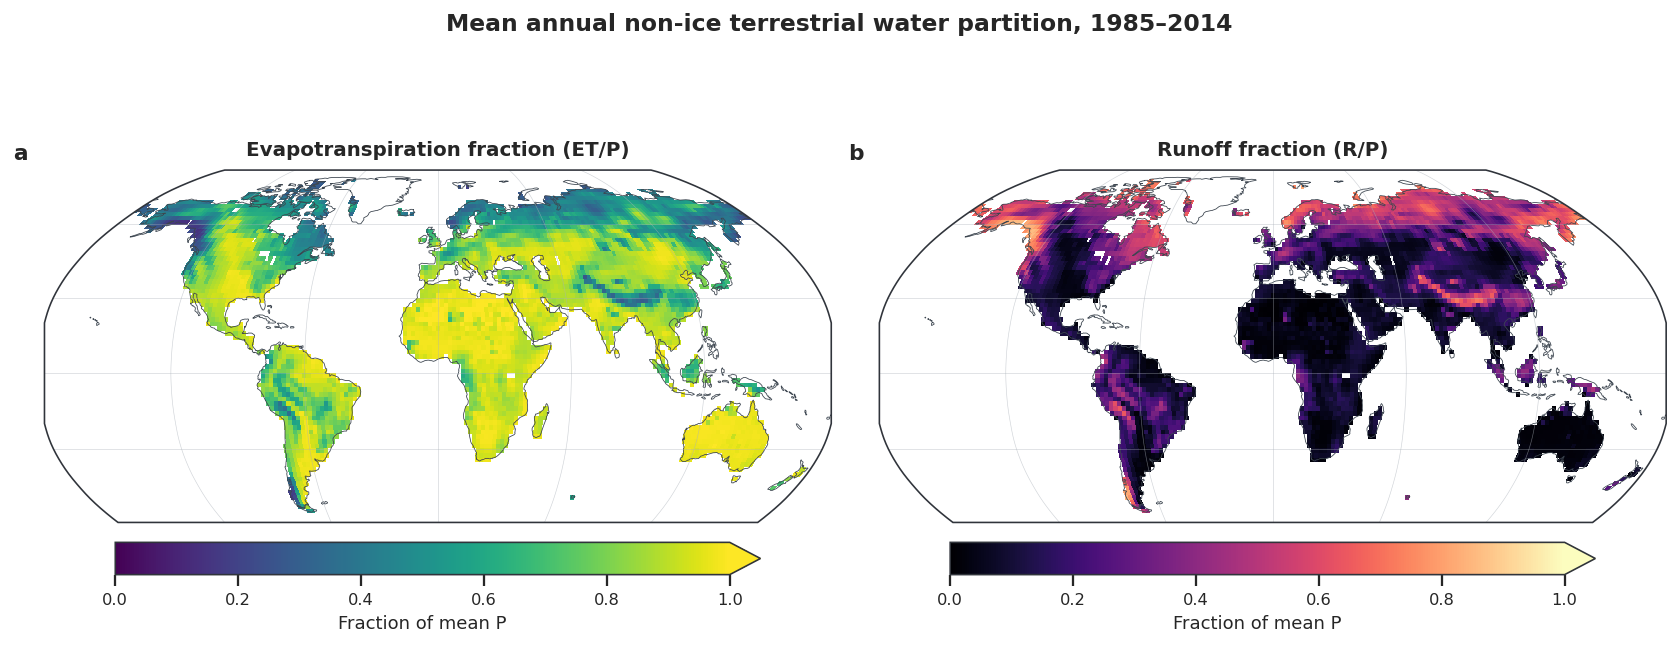

In [6]:
def metric_grid(column):
    numeric_ids = clim["grid_id_numeric"].astype(int).to_numpy()
    lookup = np.full(int(numeric_ids.max()) + 1, np.nan, dtype="float32")
    lookup[numeric_ids] = clim[column].astype(float).to_numpy()
    source_ids = spatial["grid_id"].fillna(-1).values.astype(int)
    safe_ids = np.where(source_ids > 0, source_ids, 0)
    values = lookup[safe_ids]
    values[source_ids <= 0] = np.nan
    return xr.DataArray(values, coords={"lat": spatial.lat, "lon": spatial.lon}, dims=("lat", "lon"), name=column)

def style_map(ax):
    ax.set_global()
    ax.coastlines(resolution="110m", color="#3D4650", linewidth=0.45)
    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=False,
        xlocs=np.arange(-120, 181, 60), ylocs=np.arange(-60, 91, 30),
        color="#AAB1B9", linewidth=0.35, alpha=0.55,
    )
    ax.spines["geo"].set_edgecolor("#30343B")
    ax.spines["geo"].set_linewidth(0.9)

projection = ccrs.Robinson()
fig, axes = plt.subplots(
    1, 2, figsize=(12.8, 4.7), subplot_kw={"projection": projection},
    constrained_layout=True,
)
map_specs = [
    ("ET_fraction_climatology", "Evapotranspiration fraction (ET/P)", "viridis"),
    ("R_fraction_climatology", "Runoff fraction (R/P)", "magma"),
]
for panel, (ax, (column, title, cmap)) in enumerate(zip(axes, map_specs)):
    mesh = ax.pcolormesh(
        spatial.lon, spatial.lat, metric_grid(column),
        transform=ccrs.PlateCarree(), cmap=cmap, vmin=0, vmax=1,
        shading="auto", rasterized=True,
    )
    style_map(ax)
    ax.set_title(title, pad=8)
    ax.text(-0.04, 1.03, chr(97 + panel), transform=ax.transAxes, fontweight="bold")
    colorbar = fig.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.035, shrink=0.82, extend="max")
    colorbar.set_label("Fraction of mean P")
fig.suptitle("Mean annual non-ice terrestrial water partition, 1985–2014", y=1.02, fontsize=13, fontweight="semibold")
fig.savefig(FIGURE_DIR / "climatology_partition_maps.png", bbox_inches="tight")
plt.show()


## Step 6 — Check long-term water-balance closure

**English.** Examine WB/P and the partition sum (ET + R)/P. This determines whether apparent fraction patterns are physically interpretable or dominated by residual imbalance. Plotting limits use robust quantiles only for visibility; all grids remain in the calculations and saved table.

**中文。** 检查 WB/P 和总分配比例 (ET + R)/P，以判断比例空间结构是否具有水量平衡基础，还是被残差主导。为了看清主体分布，绘图范围使用稳健分位数，但所有网格仍保留在计算和输出表中。


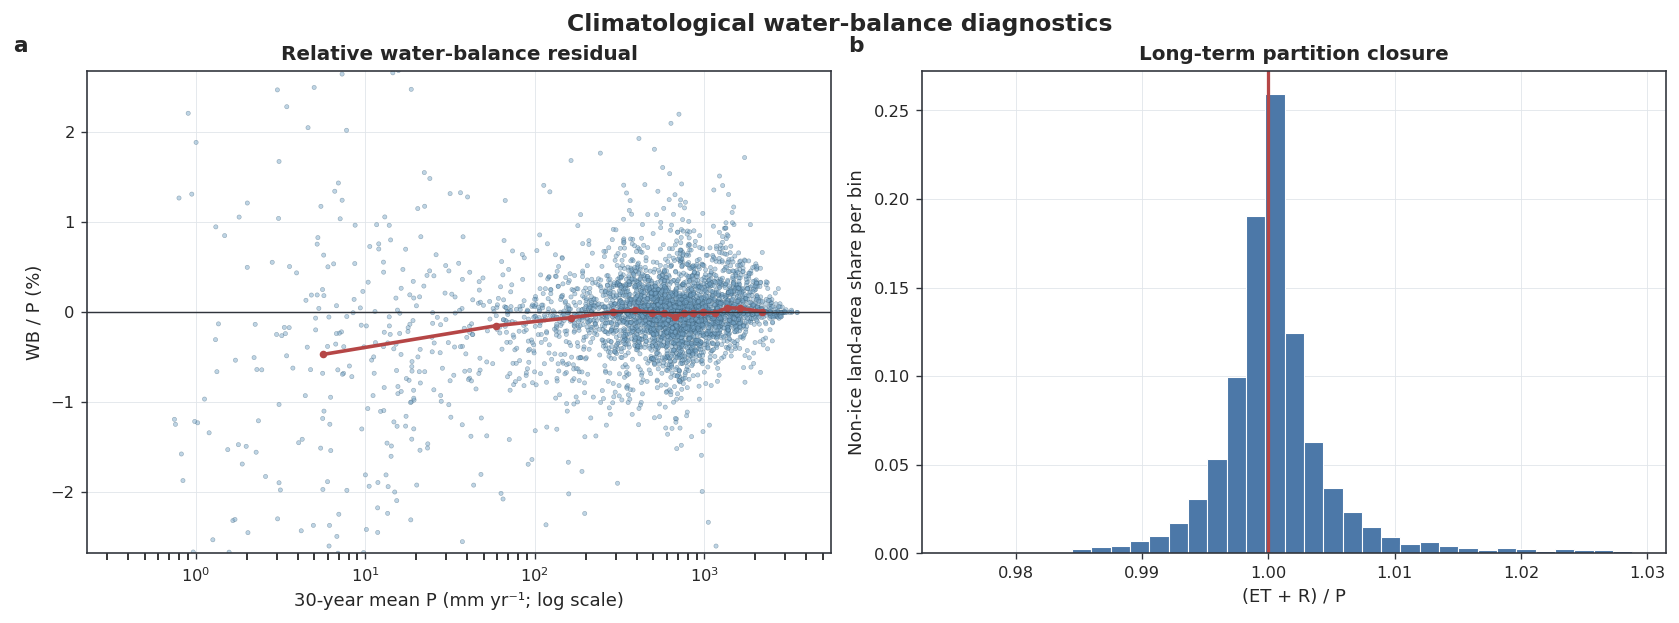

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5), constrained_layout=True)

axes[0].scatter(
    clim["P"], 100 * clim["WB_fraction_climatology"], s=point_sizes,
    color="#78A6C8", alpha=0.48, edgecolors="#31566E", linewidths=0.28,
    rasterized=True,
)
wb_curve = weighted_binned_summary(clim, "P", ["WB_fraction_climatology"])
axes[0].plot(
    wb_curve["P_median"], 100 * wb_curve["WB_fraction_climatology_median"],
    color="#B54646", linewidth=2, marker="o", markersize=3.2,
)
axes[0].axhline(0, color="#30343B", linewidth=0.8)
axes[0].set_xscale("log")
wb_limit = 100 * float(clim["WB_fraction_climatology"].abs().quantile(0.99))
axes[0].set_ylim(-wb_limit, wb_limit)
axes[0].set_xlabel("30-year mean P (mm yr⁻¹; log scale)")
axes[0].set_ylabel("WB / P (%)")
axes[0].set_title("Relative water-balance residual")
style_axes(axes[0])

closure_low = float(clim["partition_sum_climatology"].quantile(0.005))
closure_high = float(clim["partition_sum_climatology"].quantile(0.995))
closure_bins = np.linspace(closure_low, closure_high, 36)
axes[1].hist(
    clim["partition_sum_climatology"], bins=closure_bins,
    weights=weights / weights.sum(), color="#4C78A8",
    edgecolor="white", linewidth=0.6,
)
axes[1].axvline(1, color="#B54646", linewidth=1.8)
axes[1].set_xlabel("(ET + R) / P")
axes[1].set_ylabel("Non-ice land-area share per bin")
axes[1].set_title("Long-term partition closure")
style_axes(axes[1])

for panel, ax in enumerate(axes):
    ax.text(-0.10, 1.04, chr(97 + panel), transform=ax.transAxes, fontweight="bold")
fig.suptitle("Climatological water-balance diagnostics", y=1.03, fontsize=13, fontweight="semibold")
fig.savefig(FIGURE_DIR / "climatology_water_balance_diagnostics.png", bbox_inches="tight")
plt.show()


## Step 7 — Köppen readiness without circular classification

**English.** Search the case directory for a Köppen or climate-zone raster. None is required for this Step 4 analysis. If no file is present, do not infer “wet/dry” classes from P, ET, or R and then use those same fluxes to demonstrate class differences; that would be circular. The saved table retains `grid_id`, latitude, and longitude for a later nearest-neighbor or conservative join to an external Köppen product.

**中文。** 检查 case 目录是否存在 Köppen 或气候分区栅格。本 Step 4 不依赖这类文件。如果当前没有分类数据，不应先用 P、ET、R 本身定义“干/湿”类别，再用同一组变量证明类别存在差异，因为这会产生循环论证。输出表保留 `grid_id`、纬度和经度，方便后续与独立 Köppen 产品进行最近邻或保守匹配。


In [8]:
climate_candidates = sorted({
    *CASE_DIR.rglob("*koppen*.nc"),
    *CASE_DIR.rglob("*koppen*.csv"),
    *CASE_DIR.rglob("*climate*zone*.nc"),
    *CASE_DIR.rglob("*climate*zone*.csv"),
})
if climate_candidates:
    print("Potential climate-class files found:")
    for path in climate_candidates:
        print(f"  - {path}")
else:
    print("No Köppen or grid-matched climate-zone file is currently present in case/caseA.")
    print("Step 4 therefore remains a continuous spatial relationship analysis.")


Potential climate-class files found:
  - /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/MPI_ESM1_2_LR_koppen_zone_purity_sensitivity_1985_2014.csv
  - /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/MPI_ESM1_2_LR_koppen_zone_summary_1985_2014.csv
  - /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/MPI_ESM1_2_LR_koppen_zones_1985_2014.nc
  - /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/koppen_geiger_0p1.nc


## Step 8 — Save the analysis-ready spatial products

**English.** Save the explicit ratio-of-means fractions, spatial association table, equal-area precipitation-bin summary, gridded NetCDF, and four figures. These outputs are the direct input for a later Köppen comparison or tree analysis.

**中文。** 保存明确采用“平均值之比”的水分分配比例、空间关系统计、等面积降水分箱汇总、网格化 NetCDF 和四幅图。这些结果可直接用于后续 Köppen 对比或 tree 分析。


In [9]:
EDA_PARQUET = DERIVED_DIR / "MPI_ESM1_2_LR_climatology_spatial_EDA_1985_2014.parquet"
EDA_NETCDF = DERIVED_DIR / "MPI_ESM1_2_LR_climatology_partition_1985_2014.nc"
CORRELATION_CSV = DERIVED_DIR / "MPI_ESM1_2_LR_climatology_spatial_correlations_1985_2014.csv"
BIN_SUMMARY_CSV = DERIVED_DIR / "MPI_ESM1_2_LR_precipitation_partition_bins_1985_2014.csv"

gridded = xr.Dataset({
    "P": metric_grid("P"),
    "ET": metric_grid("ET"),
    "R": metric_grid("R"),
    "WB": metric_grid("WB"),
    "ET_fraction_climatology": metric_grid("ET_fraction_climatology"),
    "R_fraction_climatology": metric_grid("R_fraction_climatology"),
    "WB_fraction_climatology": metric_grid("WB_fraction_climatology"),
    "partition_sum_climatology": metric_grid("partition_sum_climatology"),
    "grid_id": spatial["grid_id"].fillna(-1).astype("int32"),
    "analysis_cell": spatial["analysis_cell"].astype("int8"),
    "land_area": spatial["land_area"].astype("float32"),
})
for variable in ["P", "ET", "R", "WB"]:
    gridded[variable].attrs["units"] = "mm yr-1"
for variable in [
    "ET_fraction_climatology", "R_fraction_climatology",
    "WB_fraction_climatology", "partition_sum_climatology",
]:
    gridded[variable].attrs["units"] = "1"
gridded.attrs.update({
    "title": "MPI-ESM1-2-LR 1985-2014 climatological terrestrial water partition",
    "source_id": spatial.attrs.get("source_id"),
    "variant_label": spatial.attrs.get("variant_label"),
    "grid_label": spatial.attrs.get("grid_label"),
    "experiment_id": spatial.attrs.get("experiment_id"),
    "analysis_period": f"{START_YEAR}-{END_YEAR}",
    "fraction_definition": "ratio of 30-year mean fluxes",
})

if WRITE_OUTPUTS:
    DERIVED_DIR.mkdir(parents=True, exist_ok=True)
    clim.to_parquet(EDA_PARQUET, index=False)
    correlation_summary.to_csv(CORRELATION_CSV)
    precipitation_bins.to_csv(BIN_SUMMARY_CSV, index=False)
    encoding = {name: {"zlib": True, "complevel": 4} for name in gridded.data_vars}
    gridded.to_netcdf(EDA_NETCDF, encoding=encoding)

manifest = pd.DataFrame([
    {"product": "Spatial EDA table", "path": EDA_PARQUET, "rows_or_cells": len(clim)},
    {"product": "Gridded partition fields", "path": EDA_NETCDF, "rows_or_cells": int(spatial.analysis_cell.sum())},
    {"product": "Spatial correlations", "path": CORRELATION_CSV, "rows_or_cells": len(correlation_summary)},
    {"product": "Precipitation-bin summary", "path": BIN_SUMMARY_CSV, "rows_or_cells": len(precipitation_bins)},
    {"product": "Figure directory", "path": FIGURE_DIR, "rows_or_cells": len(list(FIGURE_DIR.glob("*.png")))},
])
manifest["exists"] = manifest["path"].map(Path.exists)
manifest["size_MB"] = manifest["path"].map(
    lambda path: np.nan if path.is_dir() else path.stat().st_size / 1e6
)
display(manifest)


,product,path,rows_or_cells,exists,size_MB
0,Spatial EDA table,/Users/mimi/Documents/Code/Github/GSA-work/exp...,4172,True,0.326700
1,Gridded partition fields,/Users/mimi/Documents/Code/Github/GSA-work/exp...,4172,True,0.195278
2,Spatial correlations,/Users/mimi/Documents/Code/Github/GSA-work/exp...,5,True,0.000284
3,Precipitation-bin summary,/Users/mimi/Documents/Code/Github/GSA-work/exp...,15,True,0.005877
4,Figure directory,/Users/mimi/Documents/Code/Github/GSA-work/exp...,4,True,NaN


## Step 9 — Key results and interpretation limits

**English.** Summarize the dominant spatial relationships and closure. Strong spatial association does not imply that P alone causally controls ET or R; it may reflect shared temperature, radiation, vegetation, topographic, and circulation gradients. Spatial autocorrelation also means the 4,172 cells are not 4,172 independent replicates. Those issues matter when moving from EDA to inference or prediction.

**中文。** 汇总主要空间关系和水量闭合情况。较强的空间相关并不意味着 P 单独因果控制 ET 或 R，因为这些关系也可能反映共同的温度、辐射、植被、地形和环流梯度。空间自相关还意味着 4,172 个网格并不是 4,172 个完全独立的重复样本；从 EDA 进入推断或预测时必须处理这些问题。


In [10]:
def area_share(mask):
    mask = pd.Series(mask, index=clim.index).fillna(False)
    return float(weights[mask].sum() / weights.sum())

key_results = pd.Series({
    "area_weighted_spatial_r_P_ET": correlation_summary.loc["P–ET", "area_weighted_Pearson_r"],
    "area_weighted_spatial_r_P_R": correlation_summary.loc["P–R", "area_weighted_Pearson_r"],
    "area_weighted_spatial_r_ET_R": correlation_summary.loc["ET–R", "area_weighted_Pearson_r"],
    "area_weighted_median_ET_fraction": weighted_quantile(clim["ET_fraction_climatology"], weights),
    "area_weighted_median_R_fraction": weighted_quantile(clim["R_fraction_climatology"], weights),
    "land_area_share_R_greater_than_ET": area_share(clim["R"] > clim["ET"]),
    "land_area_share_abs_WB_over_P_le_1_percent": area_share(clim["WB_fraction_climatology"].abs() <= 0.01),
    "land_area_share_abs_WB_over_P_le_5_percent": area_share(clim["WB_fraction_climatology"].abs() <= 0.05),
})
display(key_results.to_frame("value").round(4))


,value
area_weighted_spatial_r_P_ET,0.9086
area_weighted_spatial_r_P_R,0.7173
area_weighted_spatial_r_ET_R,0.3608
area_weighted_median_ET_fraction,0.8777
area_weighted_median_R_fraction,0.1224
land_area_share_R_greater_than_ET,0.1110
land_area_share_abs_WB_over_P_le_1_percent,0.9327
land_area_share_abs_WB_over_P_le_5_percent,0.9951


## Step 10 — Completion checklist

**English.** Reopen the saved products and verify one unique row per grid, consistent gridded cell count, finite primary quantities, and four saved figures.

**中文。** 重新打开保存结果，检查是否每个网格唯一一行、空间网格数量一致、主要变量均为有限值，并确认四幅图已保存。


In [11]:
reopened_table = pd.read_parquet(EDA_PARQUET)
reopened_grid = xr.open_dataset(EDA_NETCDF)

completion = pd.Series({
    "table_rows": len(reopened_table),
    "unique_grid_ids": reopened_table["grid_id"].nunique(),
    "gridded_analysis_cells": int(reopened_grid["analysis_cell"].sum()),
    "missing_primary_values": int(reopened_table[["P", "ET", "R", "WB"]].isna().sum().sum()),
    "saved_png_figures": len(list(FIGURE_DIR.glob("*.png"))),
})
display(completion.to_frame("value"))

assert completion["table_rows"] == completion["unique_grid_ids"] == int(spatial.analysis_cell.sum())
assert completion["gridded_analysis_cells"] == int(spatial.analysis_cell.sum())
assert completion["missing_primary_values"] == 0
assert completion["saved_png_figures"] == 4

reopened_grid.close()
spatial.close()
print("Step 4 completed successfully.")


,value
table_rows,4172
unique_grid_ids,4172
gridded_analysis_cells,4172
missing_primary_values,0
saved_png_figures,4


Step 4 completed successfully.
